# Diffusion Model Training (DDPM x0-prediction)

Uses a **pretrained sentence-transformer** (`all-MiniLM-L6-v2`) for text conditioning and projects both text and image features into a **shared latent space** (CLIP-style alignment + diffusion loss).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from IPython.display import display, clear_output
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sentence_transformers import SentenceTransformer

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Load text encoder (frozen — pretrained weights, not fine-tuned)
text_model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")
SBERT_DIM = 384  # output dim of MiniLM
print(f"Text encoder: all-MiniLM-L6-v2 ({SBERT_DIM}d)")

Using device: mps


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4912.93it/s]


Text encoder: all-MiniLM-L6-v2 (384d)


## 1. Generate Synthetic Shape Dataset

Dataset: (2048, 32, 32, 3) — 288 unique prompts
Examples: ['black background with purple circle', 'red triangle on black background', 'black background with teal diamond', 'yellow star on white background']


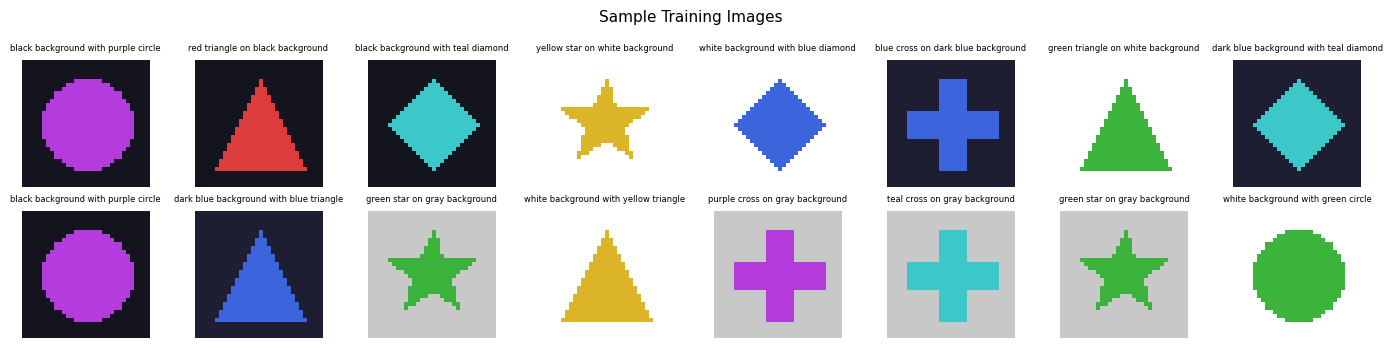

In [ ]:
IMG_SIZE = 32
N_SAMPLES = 2048
SHAPES = ["circle", "square", "triangle", "diamond", "star", "cross"]
COLORS = {
    "red": (220, 60, 60), "green": (60, 180, 60), "blue": (60, 100, 220),
    "yellow": (220, 180, 40), "purple": (180, 60, 220), "teal": (60, 200, 200),
}
BGS = {
    "white": (255, 255, 255), "gray": (200, 200, 200),
    "black": (20, 20, 30), "dark blue": (30, 30, 50),
}
COLOR_NAMES = list(COLORS.keys())
BG_NAMES = list(BGS.keys())

def draw_shape(shape, color, bg, size=IMG_SIZE):
    img = Image.new("RGB", (size, size), bg)
    d = ImageDraw.Draw(img)
    cx, cy, r = size // 2, size // 2, int(size * 0.35)
    if shape == "circle":
        d.ellipse([cx - r, cy - r, cx + r, cy + r], fill=color)
    elif shape == "square":
        d.rectangle([cx - r, cy - r, cx + r, cy + r], fill=color)
    elif shape == "triangle":
        d.polygon([(cx, cy - r), (cx + r, cy + r), (cx - r, cy + r)], fill=color)
    elif shape == "diamond":
        d.polygon([(cx, cy - r), (cx + r, cy), (cx, cy + r), (cx - r, cy)], fill=color)
    elif shape == "star":
        pts = []
        for i in range(5):
            a = np.pi / 2 + i * 2 * np.pi / 5
            pts.append((cx + np.cos(a) * r, cy - np.sin(a) * r))
            b = a + np.pi / 5
            pts.append((cx + np.cos(b) * r * 0.4, cy - np.sin(b) * r * 0.4))
        d.polygon(pts, fill=color)
    elif shape == "cross":
        w = int(r * 0.35)
        d.rectangle([cx - w, cy - r, cx + w, cy + r], fill=color)
        d.rectangle([cx - r, cy - w, cx + r, cy + w], fill=color)
    return np.array(img, dtype=np.float32) / 255.0

rng = np.random.default_rng(42)
images = []
prompts = []
for _ in range(N_SAMPLES):
    shape = rng.choice(SHAPES)
    cn = rng.choice(COLOR_NAMES)
    bn = rng.choice(BG_NAMES)
    images.append(draw_shape(shape, COLORS[cn], BGS[bn]))
    if rng.random() < 0.5:
        prompts.append(f"{cn} {shape} on {bn} background")
    else:
        prompts.append(f"{bn} background with {cn} {shape}")

images = np.stack(images)
print(f"Dataset: {images.shape} — {len(set(prompts))} unique prompts")
print(f"Examples: {prompts[:4]}")

fig, axes = plt.subplots(2, 8, figsize=(14, 3.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(prompts[i], fontsize=6)
    ax.axis("off")
fig.suptitle("Sample Training Images", fontsize=11)
plt.tight_layout()
plt.show()

## 2. Text Embeddings & Shared Latent Space

Encode prompts with the pretrained sentence-transformer (384d), then both text and images will be projected into a shared `LATENT_DIM=128` space inside the model.

In [ ]:
T = 50  # diffusion timesteps
LATENT_DIM = 128  # shared latent space for text ↔ image

# Linear beta schedule
beta = np.linspace(1e-4, 0.02, T, dtype=np.float32)
alpha = 1.0 - beta
alpha_bar = np.cumprod(alpha)

# Encode all prompts with sentence-transformer (frozen, on cpu)
print("Encoding prompts with MiniLM...")
text_vecs_raw = text_model.encode(prompts, show_progress_bar=True, convert_to_numpy=True)  # (N, 384)
print(f"Raw text embeddings: {text_vecs_raw.shape}")

# Quick sanity check: similar prompts → high cosine similarity
from numpy.linalg import norm
e1 = text_model.encode(["red circle on white background"])
e2 = text_model.encode(["white background with red circle"])
e3 = text_model.encode(["blue square on black background"])
cos12 = (e1 @ e2.T) / (norm(e1) * norm(e2))
cos13 = (e1 @ e3.T) / (norm(e1) * norm(e3))
print(f"Cosine sim (same meaning, diff order): {cos12.item():.3f}")
print(f"Cosine sim (different image):          {cos13.item():.3f}")

# Helper to embed a prompt at inference time
def text_embed(prompt):
    return text_model.encode([prompt], convert_to_numpy=True)[0]  # (384,)

# Convert to tensors
x_data = torch.from_numpy(images.transpose(0, 3, 1, 2))       # (N, 3, H, W)
t_data = torch.from_numpy(text_vecs_raw).float()                # (N, 384)
dataset = TensorDataset(x_data, t_data)
print(f"\nx_data: {x_data.shape}, text_vecs: {t_data.shape}")

Encoding prompts with MiniLM...


Batches: 100%|██████████| 64/64 [00:04<00:00, 14.71it/s]

Raw text embeddings: (2048, 384)
Cosine sim (same meaning, diff order): 0.952
Cosine sim (different image):          0.544

x_data: torch.Size([2048, 3, 32, 32]), text_vecs: torch.Size([2048, 384])


## 3. Model — shared latent space denoiser

Both text (384d → LATENT_DIM) and image (conv encoder → LATENT_DIM) are projected into the same 128d space. A CLIP-style contrastive loss aligns them during training alongside the diffusion MSE loss.

In [ ]:
class TextProjector(nn.Module):
    """Projects SBERT 384d → shared LATENT_DIM, then broadcasts to spatial map."""
    def __init__(self, sbert_dim, latent_dim, img_size):
        super().__init__()
        self.to_latent = nn.Sequential(nn.Linear(sbert_dim, latent_dim), nn.ReLU())
        self.to_spatial = nn.Sequential(nn.Linear(latent_dim, img_size * img_size))
        self.img_size = img_size

    def forward(self, txt_raw):
        z = self.to_latent(txt_raw)
        s = self.to_spatial(z)
        return z, s.view(-1, 1, self.img_size, self.img_size)

class ImageEncoder(nn.Module):
    """Projects image → shared LATENT_DIM (for contrastive alignment)."""
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, latent_dim),
        )

    def forward(self, x):
        return self.net(x)

class TimeEmbedding(nn.Module):
    def __init__(self, dim, img_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, dim), nn.ReLU(),
            nn.Linear(dim, img_size * img_size),
        )
        self.img_size = img_size

    def forward(self, t):
        return self.net(t).view(-1, 1, self.img_size, self.img_size)

class DiffusionUNet(nn.Module):
    def __init__(self, img_size=32, sbert_dim=384, latent_dim=128, time_dim=64):
        super().__init__()
        self.text_proj = TextProjector(sbert_dim, latent_dim, img_size)
        self.img_enc = ImageEncoder(latent_dim)
        self.time_emb = TimeEmbedding(time_dim, img_size)
        # Wider channels for more capacity
        self.down1 = nn.Sequential(nn.Conv2d(5, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.ReLU())
        self.down2 = nn.Sequential(nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.GroupNorm(8, 128), nn.ReLU())
        self.mid   = nn.Sequential(nn.Conv2d(128, 128, 3, padding=1), nn.GroupNorm(8, 128), nn.ReLU())
        self.up1   = nn.Sequential(nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.GroupNorm(8, 64), nn.ReLU())
        self.out   = nn.Sequential(nn.Conv2d(128, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 3, 1), nn.Sigmoid())

    def forward(self, x_noisy, t_norm, txt_raw):
        txt_z, txt_map = self.text_proj(txt_raw)
        t_map = self.time_emb(t_norm)
        x = torch.cat([x_noisy, t_map, txt_map], dim=1)
        d1 = self.down1(x)
        d2 = self.down2(d1)
        m = self.mid(d2)
        u1 = self.up1(m)
        u1 = torch.cat([u1, d1], dim=1)  # skip connection
        return self.out(u1)

    def encode_image(self, x_clean):
        return self.img_enc(x_clean)

    def encode_text(self, txt_raw):
        return self.text_proj.to_latent(txt_raw)

def clip_loss(img_z, txt_z, temperature=0.07):
    """Symmetric contrastive loss (CLIP-style) over a batch."""
    img_z = F.normalize(img_z, dim=-1)
    txt_z = F.normalize(txt_z, dim=-1)
    logits = img_z @ txt_z.T / temperature
    labels = torch.arange(len(logits), device=logits.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

model = DiffusionUNet(IMG_SIZE, SBERT_DIM, LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {n_params:,}  (SBERT {SBERT_DIM}d → shared {LATENT_DIM}d)")

Model params: 706,051  (SBERT 384d → shared 128d)


## 4. Train with live loss curve & sample grid

In [ ]:
@torch.no_grad()
def generate_samples(model, prompts_list, n=8):
    """DDPM reverse diffusion (x0-prediction)."""
    model.eval()
    txt = torch.from_numpy(np.stack([text_embed(p) for p in prompts_list[:n]])).float().to(device)
    x = torch.randn(n, 3, IMG_SIZE, IMG_SIZE, device=device)
    for t_idx in reversed(range(T)):
        t_in = torch.full((n, 1), t_idx / T, device=device)
        x0_pred = model(x, t_in, txt)
        if t_idx > 0:
            ab_t, ab_prev = alpha_bar[t_idx], alpha_bar[t_idx - 1]
            c1 = np.sqrt(ab_prev) * beta[t_idx] / (1 - ab_t)
            c2 = np.sqrt(alpha[t_idx]) * (1 - ab_prev) / (1 - ab_t)
            mu = x0_pred * c1 + x * c2
            sigma = np.sqrt(beta[t_idx] * (1 - ab_prev) / (1 - ab_t))
            x = mu + sigma * torch.randn_like(x)
        else:
            x = x0_pred
    model.train()
    return x.clamp(0, 1).cpu().numpy().transpose(0, 2, 3, 1)

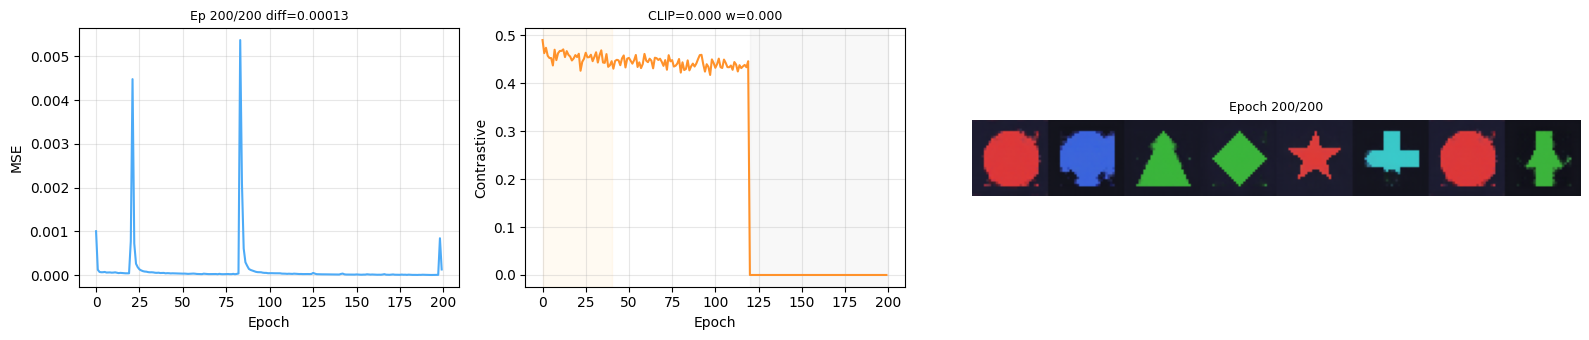

Done. Diffusion: 0.000133, CLIP: 0.0000


In [ ]:
# ── Training config ──
EPOCHS = 200
BATCH_SIZE = 64
LR = 1e-3
PREVIEW_EVERY = 20
CLIP_WEIGHT = 0.1      # contrastive loss weight
CLIP_WARMUP = 40       # ramp CLIP loss up over this many epochs
CLIP_STOP = 120        # stop CLIP loss after this epoch (let diffusion dominate)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
alpha_bar_t = torch.from_numpy(alpha_bar).to(device)

loss_history = []
clip_history = []
sample_prompts = [
    "red circle on white background",
    "blue square on black background",
    "green triangle on gray background",
    "yellow diamond on white background",
    "purple star on dark blue background",
    "teal cross on black background",
    "white background with red circle",
    "black background with green square",
]
sample_grids = {}

fig_live, axes_live = plt.subplots(1, 3, figsize=(16, 3.5),
    gridspec_kw={"width_ratios": [1, 1, 1.6]})
ax_loss, ax_clip, ax_samples = axes_live
dh = display(fig_live, display_id=True)

model.train()
for epoch in range(1, EPOCHS + 1):
    # Schedule: ramp up CLIP weight, then turn it off
    if epoch <= CLIP_WARMUP:
        cw = CLIP_WEIGHT * epoch / CLIP_WARMUP
    elif epoch <= CLIP_STOP:
        cw = CLIP_WEIGHT
    else:
        cw = 0.0

    ep_diff, ep_clip, steps = 0.0, 0.0, 0
    for x_clean, txt in loader:
        x_clean, txt = x_clean.to(device), txt.to(device)
        bs = x_clean.size(0)

        t_idx = torch.randint(0, T, (bs,), device=device)
        sqrt_ab = alpha_bar_t[t_idx].view(bs, 1, 1, 1).sqrt()
        sqrt_1_ab = (1 - alpha_bar_t[t_idx]).view(bs, 1, 1, 1).sqrt()
        noise = torch.randn_like(x_clean)
        x_noisy = x_clean * sqrt_ab + noise * sqrt_1_ab
        t_norm = (t_idx.float() / T).unsqueeze(1)

        pred = model(x_noisy, t_norm, txt)
        diff_loss = F.mse_loss(pred, x_clean)

        if cw > 0:
            img_z = model.encode_image(x_clean)
            txt_z = model.encode_text(txt)
            c_loss = clip_loss(img_z, txt_z)
            loss = diff_loss + cw * c_loss
            ep_clip += c_loss.item()
        else:
            loss = diff_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        ep_diff += diff_loss.item()
        steps += 1

    avg_diff = ep_diff / steps
    avg_clip = ep_clip / steps if steps > 0 else 0
    loss_history.append(avg_diff)
    clip_history.append(avg_clip)

    ax_loss.clear()
    ax_loss.plot(loss_history, color="#4dabf7", linewidth=1.5)
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("MSE")
    ax_loss.set_title(f"Ep {epoch}/{EPOCHS} diff={avg_diff:.5f}", fontsize=9)
    ax_loss.grid(True, alpha=0.3)

    ax_clip.clear()
    ax_clip.plot(clip_history, color="#ff922b", linewidth=1.5)
    ax_clip.axvspan(0, CLIP_WARMUP, alpha=0.05, color="orange", label="warmup")
    ax_clip.axvspan(CLIP_STOP, EPOCHS, alpha=0.05, color="gray", label="off")
    ax_clip.set_xlabel("Epoch"); ax_clip.set_ylabel("Contrastive")
    ax_clip.set_title(f"CLIP={avg_clip:.3f} w={cw:.3f}", fontsize=9)
    ax_clip.grid(True, alpha=0.3)

    if epoch % PREVIEW_EVERY == 0 or epoch == 1 or epoch == EPOCHS:
        samples = generate_samples(model, sample_prompts, n=8)
        sample_grids[epoch] = samples
        ax_samples.clear()
        row = np.concatenate(samples, axis=1)
        ax_samples.imshow(row)
        ax_samples.set_title(f"Epoch {epoch}/{EPOCHS}", fontsize=9)
        ax_samples.axis("off")

    fig_live.tight_layout()
    dh.update(fig_live)

plt.close(fig_live)
print(f"Done. Diffusion: {loss_history[-1]:.6f}, CLIP: {clip_history[-1]:.4f}")

## 5. Final results — sample grid across training

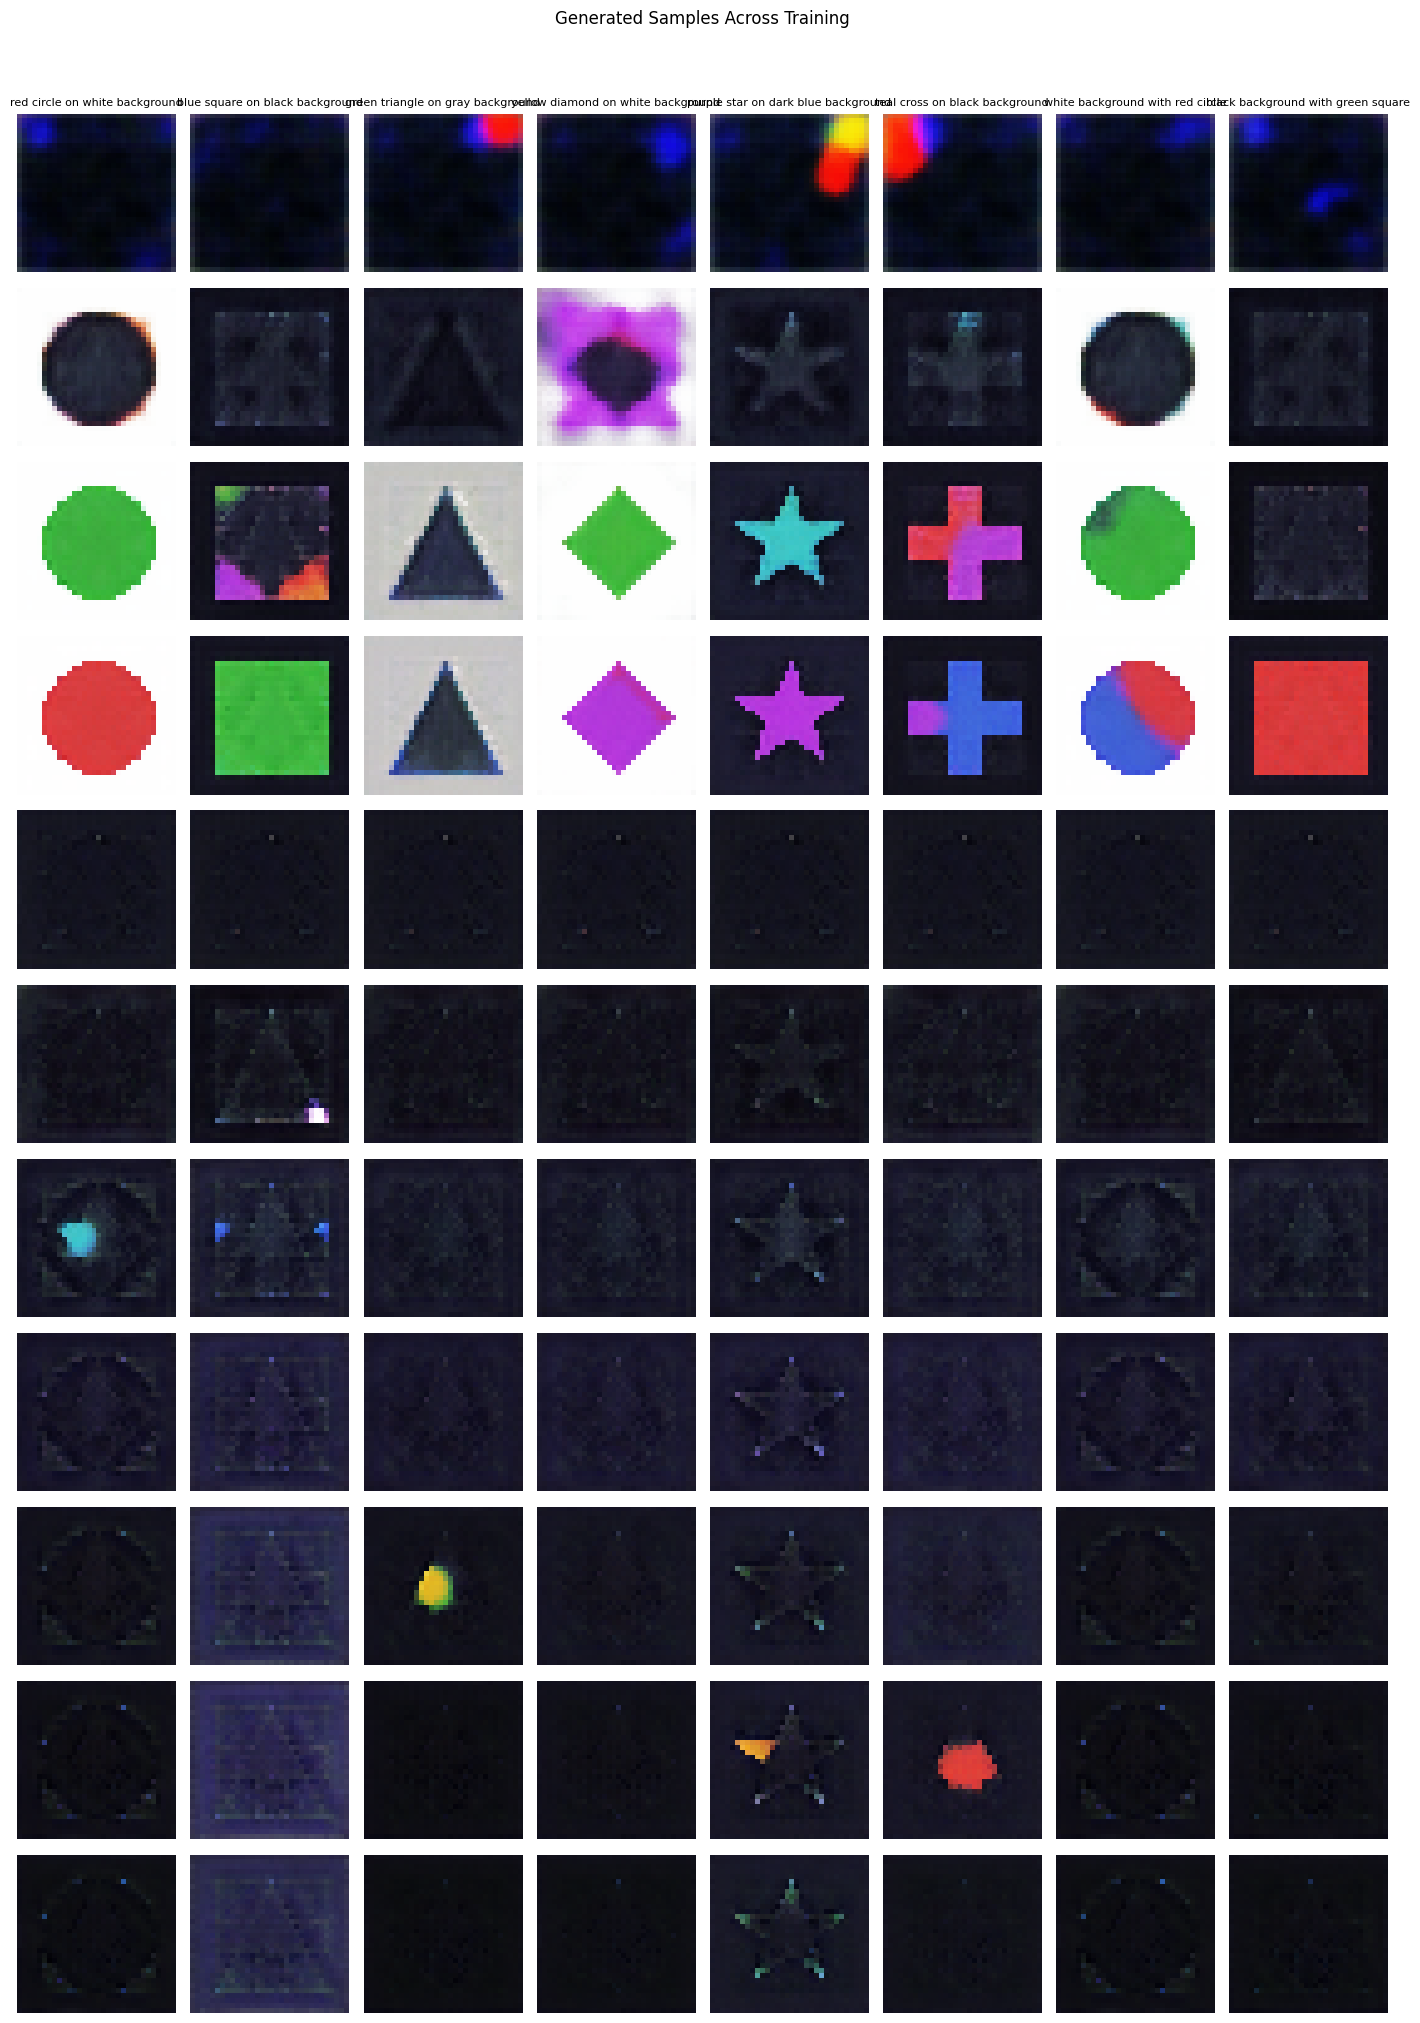

In [ ]:
# Show progression of generated samples across training
epochs_to_show = sorted(sample_grids.keys())
n_rows = len(epochs_to_show)
n_cols = 8

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 1.8))
if n_rows == 1:
    axes = [axes]

for row_idx, ep in enumerate(epochs_to_show):
    for col_idx in range(n_cols):
        ax = axes[row_idx][col_idx]
        ax.imshow(sample_grids[ep][col_idx])
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(f"ep {ep}", fontsize=9, rotation=0, labelpad=30, va="center")
        if row_idx == 0:
            ax.set_title(sample_prompts[col_idx], fontsize=8)

fig.suptitle("Generated Samples Across Training", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 6. Text-to-Image generation

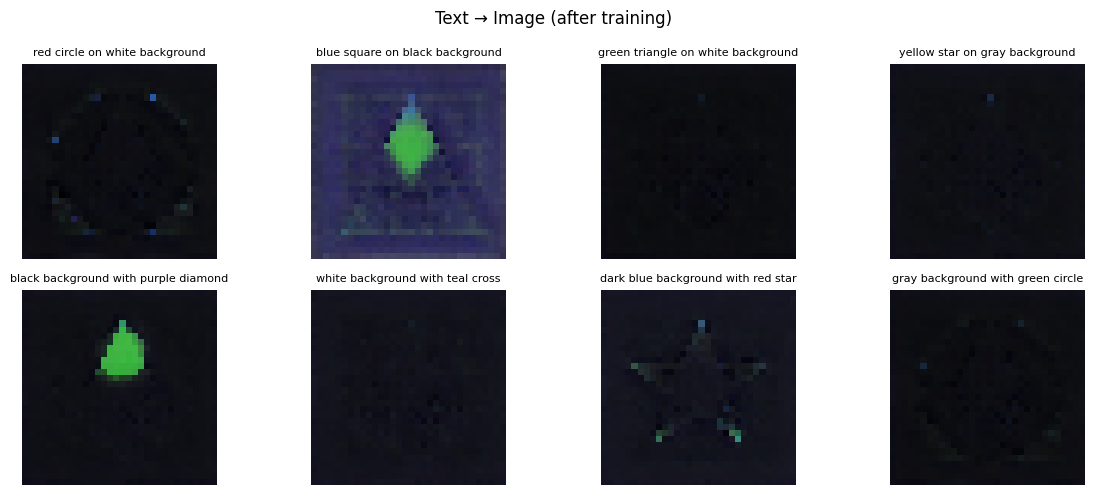

In [ ]:
test_prompts = [
    "red circle on white background",
    "blue square on black background",
    "green triangle on white background",
    "yellow star on gray background",
    "black background with purple diamond",
    "white background with teal cross",
    "dark blue background with red star",
    "gray background with green circle",
]

samples = generate_samples(model, test_prompts, n=len(test_prompts))

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i])
    ax.set_title(test_prompts[i], fontsize=8)
    ax.axis("off")
fig.suptitle("Text → Image (after training)", fontsize=12)
plt.tight_layout()
plt.show()